In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
from torch.utils.data import DataLoader
from dataset import (
    MaridaDatasetLoader,
    find_patch_bases,
    do_img_conf_mask_exist,
)
from preprocessing import (
    normalize_image,
    set_low_conf_for_nan,
    apply_augmentations,
    build_conf_ignore_mask,
    apply_ignore_index_to_target,
    flatten_for_rf,
    compute_dataset_stats,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score, jaccard_score
from unet import UNet
from preprocessing import (
    normalize_image, set_low_conf_for_nan, apply_augmentations,
    build_conf_ignore_mask, apply_ignore_index_to_target
)

import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np

In [3]:

########################
# 1. TRANSFORMS
########################

def train_transform(img, mask, conf):
    """
    Préprocessing appliqué pendant l'entraînement :
    - normalisation
    - NaN/Inf -> conf=3 + img nettoyée
    - augmentations géométriques
    """
    # Normalisation (simple float)
    img = normalize_image(img)

    # Gérer les NaN/Inf -> conf = 3, img nettoyée
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)

    # Augmentations
    img, mask, conf = apply_augmentations(
        img,
        mask,
        conf,
        p_hflip=0.5,
        p_vflip=0.5,
        p_rotate90=0.5,
    )

    return img, mask, conf


def val_transform(img, mask, conf):
    """
    Préprocessing pour validation / test :
    - normalisation
    - NaN/Inf -> conf=3
    PAS d'augmentations.
    """
    img = normalize_image(img)
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)
    return img, mask, conf


In [4]:
def fix_base_name(base):
    """
    Prend '1-12-19_48MYU_0'
    et retourne 'S2_1-12-19_48MYU/S2_1-12-19_48MYU_0'
    """
    # Exemple : base = "1-12-19_48MYU_0"
    tile = base.rsplit("_", 1)[0]      # → "1-12-19_48MYU"
    folder = "S2_" + tile              # → "S2_1-12-19_48MYU"
    full = f"{folder}/S2_{base}"       # → "S2_1-12-19_48MYU/S2_1-12-19_48MYU_0"
    return full

In [5]:
def train_transform(img, mask, conf):
    # 1) Normaliser (juste cast en float)
    img = normalize_image(img)

    # 2) Si NaN/Inf -> conf = 3 et remplacer NaN par 0
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)

    # 3) Augmentations (flip / rotate) seulement sur le train
    img, mask, conf = apply_augmentations(img, mask, conf)

    return img, mask, conf


def val_transform(img, mask, conf):
    # Val/test : on veut du déterministe → pas d’augmentations
    img = normalize_image(img)
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)
    return img, mask, conf


In [6]:
########################
# 2. CONSTRUCTION DES DATASETS
########################

def build_bases(folder):
    """Retourne une liste de bases pour lesquelles img + mask + conf existent."""
    all_bases = find_patch_bases(folder)
    bases = [b for b in all_bases if do_img_conf_mask_exist(folder, b)]
    print(f"{folder} : {len(bases)} patches valides trouvés.")
    return bases

def load_split_list(split_file):
    """
    Lit un fichier de split (train / val / test)
    et retourne une liste de bases (strings) relatives à 'patches/'.
    Exemple de ligne dans le fichier : S2A_.../patch_0001
    """
    bases = []
    with open(split_file, "r") as f:
        for line in f:
            name = line.strip()
            if not name:
                continue
            # au cas où quelqu'un aurait mis .tif dans le fichier
            if name.endswith(".tif"):
                name = name[:-4]
            bases.append(name)
    return bases

def make_dataloaders(data_root, batch_size=4):
    """
    data_root = dossier 'raw' qui contient :
        - patches/
        - splits/ (train, val, test)
    """
    patches_root = os.path.join(data_root, "patches")
    splits_dir   = os.path.join(data_root, "splits")

    train_file = os.path.join(splits_dir, "train_X.txt")
    val_file   = os.path.join(splits_dir, "val_X.txt")

    # Charger les listes de bases depuis les fichiers
    train_bases = load_split_list(train_file)
    val_bases   = load_split_list(val_file)
    train_bases = [fix_base_name(b) for b in train_bases]
    val_bases   = [fix_base_name(b) for b in val_bases]

    # Vérifier que les fichiers .tif / _cl / _conf existent
    train_bases = [
        b for b in train_bases
        if do_img_conf_mask_exist(patches_root, b)
    ]
    val_bases = [
        b for b in val_bases
        if do_img_conf_mask_exist(patches_root, b)
    ]

    print(f"Train : {len(train_bases)} patches valides.")
    print(f"Val   : {len(val_bases)} patches valides.")

    train_dataset = MaridaDatasetLoader(
    folder=patches_root,
    bases=train_bases,
    transform=train_transform,
    )

    val_dataset = MaridaDatasetLoader(
    folder=patches_root,
    bases=val_bases,
    transform=val_transform,
    )


    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    return train_loader, val_loader

In [7]:
def make_test_loader(data_root, batch_size=4):
    patches_root = os.path.join(data_root, "patches")
    splits_dir   = os.path.join(data_root, "splits")

    test_file = os.path.join(splits_dir, "test_X.txt")
    test_bases = load_split_list(test_file)
    test_bases = [
        b for b in test_bases
        if do_img_conf_mask_exist(patches_root, b)
    ]

    test_dataset = MaridaDatasetLoader(
        folder=patches_root,
        bases=test_bases,
        transform=val_transform,   # pas d'augmentations pour test
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    return test_loader


In [8]:
########################
# 3. EXEMPLE: CALCUL DES STATS
########################

def compute_stats_on_whole_dataset(data_root, batch_size=4):
    """
    Exemple de calcul de mean/std globales sur le dataset (sans augmentation).
    On utilise val_transform (sans aug) ou une transform spéciale si tu préfères.
    """
    train_folder = os.path.join(data_root, "train_X.txt")
    val_folder   = os.path.join(data_root, "val_X.txt")

    train_bases = build_bases(train_folder)
    val_bases   = build_bases(val_folder)

    # Dataset sans augmentation (val_transform)
    full_dataset = torch.utils.data.ConcatDataset([
        MaridaDatasetLoader(folder=train_folder, bases=train_bases, transform=val_transform),
        MaridaDatasetLoader(folder=val_folder, bases=val_bases, transform=val_transform),
    ])

    full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

    mean, std = compute_dataset_stats(full_loader)
    print("Mean per band:", mean)
    print("Std per band:", std)
    return mean, std

In [9]:
########################
# 4. EXEMPLE: BOUCLE D'ENTRAÎNEMENT (pseudo-code)
########################

def train_one_epoch(model, train_loader, optimizer, criterion, device="cpu"):
    model.train()

    for batch_idx, (imgs, masks, confs) in enumerate(train_loader):
        # imgs : (B, C, H, W)
        # masks: (B, H, W)
        # confs: (B, H, W)

        imgs  = imgs.to(device)
        masks = masks.to(device)
        confs = confs.to(device)

        # 1) Construire le target avec ignore_index basé sur la confidence
        targets_for_loss = []
        for b in range(imgs.shape[0]):
            conf_b = confs[b]   # (H, W)
            mask_b = masks[b]   # (H, W)

            ignore_mask = build_conf_ignore_mask(conf_b, threshold=2)
            target_mod  = apply_ignore_index_to_target(
                mask_b,
                ignore_mask,
                ignore_index=-100,
            )
            targets_for_loss.append(target_mod)

        targets_for_loss = torch.stack(targets_for_loss, dim=0)  # (B, H, W)

        # 2) Forward
        optimizer.zero_grad()
        logits = model(imgs)   # (B, num_classes, H, W) par exemple

        # 3) Loss (par ex. CrossEntropy2D avec ignore_index=-100)
        loss = criterion(logits, targets_for_loss)

        # 4) Backprop
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}, loss = {loss.item():.4f}")


########################
# 5. EXEMPLE: DATASET FLATTEN POUR RANDOM FOREST
########################

def build_rf_dataset(data_root):
    """
    Construit X, y pour RandomForest à partir de tous les patches
    (train + val, à adapter selon tes besoins).
    On utilise val_transform (pas d'augmentation aléatoire).
    """
    train_folder = os.path.join(data_root, "train")
    val_folder   = os.path.join(data_root, "val")

    train_bases = build_bases(train_folder)
    val_bases   = build_bases(val_folder)

    train_dataset = MaridaDatasetLoader(
        folder=train_folder,
        bases=train_bases,
        transform=val_transform,
    )
    val_dataset = MaridaDatasetLoader(
        folder=val_folder,
        bases=val_bases,
        transform=val_transform,
    )

    rf_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])
    rf_loader  = DataLoader(rf_dataset, batch_size=1, shuffle=False)

    all_X = []
    all_y = []

    for img, mask, conf in rf_loader:
        img  = img.squeeze(0)   # (C, H, W)
        mask = mask.squeeze(0)  # (H, W)
        conf = conf.squeeze(0)  # (H, W)

        X_rf, y_rf = flatten_for_rf(img, mask, conf, conf_threshold=2)
        all_X.append(X_rf)
        all_y.append(y_rf)

    X_all = torch.cat(all_X, dim=0)
    Y_all = torch.cat(all_y, dim=0)

    print("RF dataset : X =", X_all.shape, ", y =", Y_all.shape)
    return X_all, Y_all

In [10]:
# OVIA

def build_rf_dataset_from_splits(
    data_root,
    splits=("train", "val"),
    conf_threshold=2,
    max_patches=None,
):
    """
    Construit X, y pour RandomForest à partir des splits MARIDA
    en utilisant data/raw/patches + data/raw/splits.
    On réutilise exactement la même logique que make_dataloaders :
    - load_split_list
    - fix_base_name
    - do_img_conf_mask_exist
    """
    patches_root = os.path.join(data_root, "patches")
    splits_dir   = os.path.join(data_root, "splits")

    # 1) Lire les listes de patches pour chaque split
    all_bases = []
    for split in splits:
        split_file = os.path.join(splits_dir, f"{split}_X.txt")
        bases_raw = load_split_list(split_file)       # ex: "1-12-19_48MYU_0"
        bases_fix = [fix_base_name(b) for b in bases_raw]  # ex: "S2_.../S2_..._0"
        all_bases.extend(bases_fix)

    # 2) Garder seulement les patches où img + mask + conf existent
    all_bases = [
        b for b in all_bases
        if do_img_conf_mask_exist(patches_root, b)
    ]
    print(f"{len(all_bases)} patches valides pour splits {splits}")

    if len(all_bases) == 0:
        raise RuntimeError(
            f"Aucun patch valide trouvé. Vérifie data_root={data_root} "
            "et le contenu de data/raw/patches + data/raw/splits."
        )

    # 3) Dataset MARIDA avec val_transform (pas d'augmentation aléatoire)
    rf_dataset = MaridaDatasetLoader(
        folder=patches_root,
        bases=all_bases,
        transform=val_transform,
    )

    rf_loader = DataLoader(
        rf_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    # 4) Flatten en pixels pour RF
    X_list, y_list = [], []

    for i, (img, mask, conf) in enumerate(rf_loader):
        img  = img.squeeze(0)   # (C, H, W)
        mask = mask.squeeze(0)  # (H, W)
        conf = conf.squeeze(0)  # (H, W)

        X_rf, y_rf = flatten_for_rf(img, mask, conf, conf_threshold)
        X_list.append(X_rf)
        y_list.append(y_rf)

        if max_patches is not None and (i + 1) >= max_patches:
            print(f"Limité à {max_patches} patches.")
            break

    X_all = torch.cat(X_list).cpu().numpy()
    Y_all = torch.cat(y_list).cpu().numpy()

    print("RF dataset : X =", X_all.shape, ", y =", Y_all.shape)
    return X_all, Y_all


In [12]:
data_root = os.path.join(os.getcwd(), "../","data", "raw","MARIDA")
data_root = os.path.abspath(data_root)
train_loader, val_loader = make_dataloaders(data_root, batch_size=4)
test_loader = make_test_loader(data_root, batch_size=4)


Train : 694 patches valides.
Val   : 328 patches valides.


In [13]:
ds = train_loader.dataset

img1, mask1, conf1 = ds[0]
img2, mask2, conf2 = ds[0]

print("Same shape:", img1.shape, img2.shape)
print("Pixels exactly equal ?", torch.allclose(img1, img2))


Same shape: torch.Size([11, 256, 256]) torch.Size([11, 256, 256])
Pixels exactly equal ? False


In [14]:
X_all, Y_all = build_rf_dataset_from_splits(
    data_root,
    splits=("train", "val"),  # ou ("train",) si tu veux garder "val" à part
    conf_threshold=2,
)

1022 patches valides pour splits ('train', 'val')
RF dataset : X = (66902349, 11) , y = (66902349,)


In [15]:


# --- 1. SOUS-ÉCHANTILLONNAGE (Subsampling) ---
SAMPLE_SIZE = 100_000

print(f"Sous-échantillonnage à {SAMPLE_SIZE} lignes pour test rapide...")

if len(X_all) > SAMPLE_SIZE:
    # NOTE : On met stratify=None ici pour éviter le crash si une classe est trop rare
    X_sample, _, y_sample, _ = train_test_split(
        X_all,
        Y_all,
        train_size=SAMPLE_SIZE,
        stratify=None,  # Désactivé pour le test rapide pour éviter l'erreur "1 member"
        random_state=42
    )
else:
    X_sample, y_sample = X_all, Y_all

print(f"Taille de l'échantillon de travail : {X_sample.shape}")

# --- 2. SPLIT TRAIN/VAL SUR L'ÉCHANTILLON ---
print("Création des sets d'entraînement et de validation...")

# NOTE : On utilise X_sample ici, PAS X_all
X_train, X_val, y_train, y_val = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=None, # Désactivé aussi ici par sécurité pour le test
)

# --- 3. DÉFINITION ET ENTRAÎNEMENT DU MODÈLE ---
rf_model = RandomForestClassifier(
    n_estimators=10,  # Peu d'arbres pour le test
    max_depth=10,     # Profondeur limitée
    n_jobs=4,         # Pas trop de cœurs pour économiser la RAM
    random_state=0,
    verbose=1
)

print("Entraînement du RandomForest...")
rf_model.fit(X_train, y_train)

# --- 4. ÉVALUATION ---
y_train_pred = rf_model.predict(X_train)
y_val_pred   = rf_model.predict(X_val)

print("\n=== Performance RandomForest (Test Rapide) ===")
print(f"Accuracy train : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy val   : {accuracy_score(y_val,   y_val_pred):.4f}\n")

print("Classification report (val) :")
# On gère le cas où certaines classes sont absentes du rapport
try:
    print(classification_report(y_val, y_val_pred))
except Exception as e:
    print(f"Erreur rapport (peut-être classes manquantes dans le split) : {e}")

print("Matrice de confusion (val) :")
print(confusion_matrix(y_val, y_val_pred))

Sous-échantillonnage à 100000 lignes pour test rapide...
Taille de l'échantillon de travail : (100000, 11)
Création des sets d'entraînement et de validation...
Entraînement du RandomForest...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.



=== Performance RandomForest (Test Rapide) ===
Accuracy train : 0.9941
Accuracy val   : 0.9927

Classification report (val) :
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     19798
           2       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00        25
           7       0.00      0.00      0.00        29
           8       0.82      0.72      0.77        96
          10       1.00      0.03      0.05        36
          11       0.00      0.00      0.00         4
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00         3

    accuracy                           0.99     20000
   macro avg       0.26      0.16      0.17     20000
weighted avg       0.99      0.99      0.99     20000

Matrice de confusion (val) :
[[19783     0     0     0     0

[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.0s finished
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

In [ ]:

SAMPLE_SIZE = 1_000_000

if len(X_all) > SAMPLE_SIZE:
    print(f"⚠️ Jeu de données trop gros ({len(X_all)} lignes). Sous-échantillonnage à {SAMPLE_SIZE} lignes...")
    # On garde une petite partie (X_sample) et on jette le reste (_)
    X_sample, _, y_sample, _ = train_test_split(
        X_all,
        Y_all,
        train_size=SAMPLE_SIZE,
        stratify=Y_all,
        random_state=42
    )
else:
    X_sample, y_sample = X_all, Y_all

# --- Split Train/Val sur l'échantillon réduit ---
print("Création des sets d'entraînement et de validation...")
X_train, X_val, y_train, y_val = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=None,
)




rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    n_jobs=4,
    random_state=0,
    verbose=1
)

print("Entraînement du RandomForest...")
rf_model.fit(X_train, y_train)

y_train_pred = rf_model.predict(X_train)
y_val_pred   = rf_model.predict(X_val)

print("\n=== Performance RandomForest ===")
print(f"Accuracy train : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy val   : {accuracy_score(y_val,   y_val_pred):.4f}\n")

print("Classification report (val) :")
print(classification_report(y_val, y_val_pred))

print("Matrice de confusion (val) :")
print(confusion_matrix(y_val, y_val_pred))



⚠️ Jeu de données trop gros (66902349 lignes). Sous-échantillonnage à 1000000 lignes...
Création des sets d'entraînement et de validation...
Entraînement du RandomForest...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    3.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.2s finished



=== Performance RandomForest ===
Accuracy train : 0.9934
Accuracy val   : 0.9927

Classification report (val) :
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    198077
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00       234
           7       0.00      0.00      0.00       319
           8       0.81      0.73      0.76       841
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       391
          11       0.00      0.00      0.00        45
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00        25
          14       0.00      0.00      0.00        23
          15       0.0

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.0s finished
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

In [17]:
# === 1. FONCTION DE MAPPING (Simplification des classes) ===
def map_marida_classes(y):
    y_new = np.zeros_like(y)

    # Target: Marine Debris (Original 1) -> Devis 1 (Pour le rapport)
    # Attention: gardons 1 pour Trash pour la lisibilité
    mask_trash = (y == 1)

    # Floating/Confusers: Sargassum, Organic, Ship, Foam, Waves, Wakes
    # Original IDs: 2, 3, 4, 5, 9, 12, 14
    mask_confusers = np.isin(y, [2, 3, 4, 5, 9, 12, 14])

    # Background: Tout le reste (Water, Clouds, etc.)
    # Par défaut on mettra tout à 0 (Background), puis on applique les masques

    y_new[:] = 0            # Classe 0 = Water/Background
    y_new[mask_confusers] = 2 # Classe 2 = Natural/Floating (Algues, Bateaux...)
    y_new[mask_trash] = 1     # Classe 1 = TRASH (Cible)

    return y_new

Simplification des classes (Mapping)...
Total pixels disponibles - Trash: 2572, Confusers: 20552, Water: 66879225
Taille finale du Dataset d'entraînement équilibré : 123124
Entraînement sur données équilibrées...

=== Rapport de Classification (0=Water, 1=TRASH, 2=Floating) ===
Calcul des prédictions en cours...

=== Performance Globale (3 Classes) ===
Accuracy train : 1.0000
Accuracy val   : 0.9623

=== Classification Report (Validation) ===
                      precision    recall  f1-score   support

Water/Background (0)       0.97      0.99      0.98     20000
           TRASH (1)       0.96      0.94      0.95       514
Floating/Natural (2)       0.92      0.85      0.88      4111

            accuracy                           0.96     24625
           macro avg       0.95      0.92      0.94     24625
        weighted avg       0.96      0.96      0.96     24625

=== Matrice de Confusion (Validation) ===
[[19735     4   261]
 [    4   484    26]
 [  617    17  3477]]


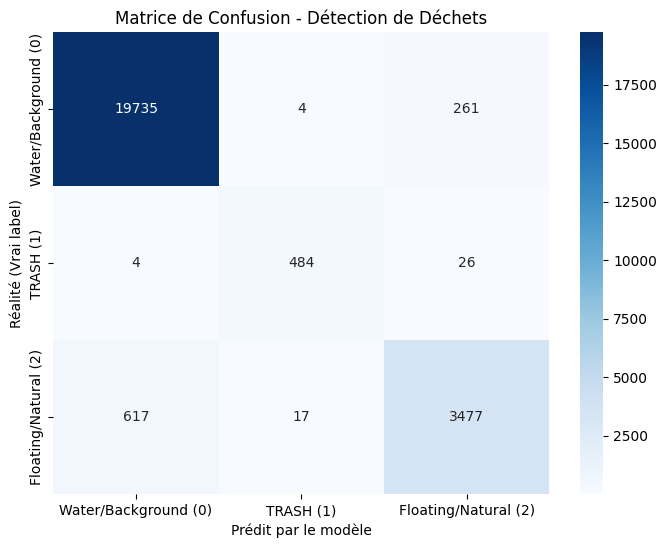

In [18]:
print("Simplification des classes (Mapping)...")
Y_mapped = map_marida_classes(Y_all)

# === 2. UNDERSAMPLING INTELLIGENT (La clé du succès !) ===
# Au lieu de prendre au hasard, on récupère les indices par classe
idx_trash = np.where(Y_mapped == 1)[0]
idx_confusers = np.where(Y_mapped == 2)[0]
idx_background = np.where(Y_mapped == 0)[0]

print(f"Total pixels disponibles - Trash: {len(idx_trash)}, Confusers: {len(idx_confusers)}, Water: {len(idx_background)}")

# On garde TOUT le plastique disponible !
# On prend un échantillon des autres pour équilibrer (ex: 50 000 de chaque)
n_samples = 50_000

# Sécurité si on a moins de 50k pixels
n_conf = min(len(idx_confusers), n_samples)
n_back = min(len(idx_background), n_samples * 2) # On prend un peu plus d'eau car c'est varié

# Choix aléatoire des indices pour l'eau et les algues
idx_confusers_sub = np.random.choice(idx_confusers, n_conf, replace=False)
idx_background_sub = np.random.choice(idx_background, n_back, replace=False)

# On fusionne tout
final_indices = np.concatenate([idx_trash, idx_confusers_sub, idx_background_sub])
np.random.shuffle(final_indices) # Mélanger pour ne pas avoir le plastique tout au début

print(f"Taille finale du Dataset d'entraînement équilibré : {len(final_indices)}")

X_balanced = X_all[final_indices]
Y_balanced = Y_mapped[final_indices]

# === 3. ENTRAÎNEMENT DU MODÈLE ===
X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, Y_balanced, test_size=0.2, random_state=42, stratify=Y_balanced
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=4,
    # Important: class_weight aide encore plus pour les déséquilibres restants
    class_weight='balanced',
    random_state=42
)

print("Entraînement sur données équilibrées...")
rf_model.fit(X_train, y_train)

# === 4. RÉSULTATS ===
print("\n=== Rapport de Classification (0=Water, 1=TRASH, 2=Floating) ===")
print("Calcul des prédictions en cours...")
y_train_pred = rf_model.predict(X_train)
y_val_pred   = rf_model.predict(X_val)

# 2. Accuracy (Précision globale)
print("\n=== Performance Globale (3 Classes) ===")
print(f"Accuracy train : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy val   : {accuracy_score(y_val,   y_val_pred):.4f}\n")

# 3. Rapport de Classification Détaillé
# On nomme les classes pour faciliter la lecture
class_names = ['Water/Background (0)', 'TRASH (1)', 'Floating/Natural (2)']

print("=== Classification Report (Validation) ===")
print(classification_report(y_val, y_val_pred, target_names=class_names))

# 4. Matrice de Confusion (Version Texte)
print("=== Matrice de Confusion (Validation) ===")
# Rappel : Lignes = Vraies classes, Colonnes = Prédictions
cm = confusion_matrix(y_val, y_val_pred)
print(cm)

# --- BONUS : Visualisation Graphique (Plus facile à lire) ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Prédit par le modèle')
plt.ylabel('Réalité (Vrai label)')
plt.title('Matrice de Confusion - Détection de Déchets')
plt.show()

In [28]:

PROJECT_PATH = os.path.join(os.getcwd(), "../")
# On ajoute 'src' au système pour les imports
sys.path.append(os.path.join(PROJECT_PATH, "src"))

# On définit les chemins de données

DATA_ROOT = os.path.join(os.getcwd(), "../","data", "raw","MARIDA")
PATCHES_DIR = os.path.join(DATA_ROOT, "patches")
SPLITS_DIR = os.path.join(DATA_ROOT, "splits")

print(f" Dossier Patches : {PATCHES_DIR}")
print(f" Dossier Textes : {SPLITS_DIR}")


# --- 3. DÉFINITION DES TRANSFORMATIONS ---
def train_transform(img, mask, conf):
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)
    img = normalize_image(img)
    img, mask, conf = apply_augmentations(img, mask, conf)
    return img, mask, conf

def val_transform(img, mask, conf):
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)
    img = normalize_image(img)
    return img, mask, conf

# --- 4. FONCTION POUR TROUVER LES IMAGES ---
def get_valid_bases(split_filename, patches_root):
    split_path = os.path.join(SPLITS_DIR, split_filename)
    if not os.path.exists(split_path):
        print(f" Fichier texte manquant : {split_path}")
        return []

    valid_bases = []
    with open(split_path, 'r') as f:
        lines = f.readlines()

    print(f" Lecture de {split_filename}...")
    for line in lines:
        name = line.strip()
        if not name: continue

        # Correction du nom : Ajout de S2_
        base_name = "S2_" + name
        folder_name = base_name.rsplit('_', 1)[0]
        relative_path = os.path.join(folder_name, base_name)

        # Vérification
        if os.path.exists(os.path.join(patches_root, relative_path + ".tif")):
            valid_bases.append(relative_path)

    print(f"    {len(valid_bases)} images trouvées.")
    return valid_bases

# --- 5. CRÉATION DES LISTES ---
train_bases = get_valid_bases("train_X.txt", PATCHES_DIR)
val_bases = get_valid_bases("val_X.txt", PATCHES_DIR)

if len(train_bases) == 0:
    raise ValueError(" ERREUR : Aucune image trouvée. Vérifiez le chemin DATA_ROOT.")

# --- 6. CRÉATION DES DATASETS ET LOADERS ---
train_dataset = MaridaDatasetLoader(PATCHES_DIR, train_bases, transform=train_transform)
val_dataset = MaridaDatasetLoader(PATCHES_DIR, val_bases, transform=val_transform)

BATCH_SIZE = 8
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

# --- 7. MODÈLE ET ENTRAÎNEMENT ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Démarrage sur : {DEVICE}")

model = UNet(n_channels=11, n_classes=15).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

EPOCHS = 15
print("\n Lancement de la boucle d'entraînement...")
# --- CORRECTION : PONDÉRATION DES CLASSES ---
# On donne un gros poids aux classes rares (Débris, Mousse) et un petit poids aux classes fréquentes (Eau)
# Ordre : 0=Débris, 1=Sargasses D, 2=Sargasses S, 3=Orga, 4=Navire, 5=Nuages, 6=Eau, etc.

# Poids approximatifs basés sur vos résultats (Inverse de la fréquence)
# Débris (Class 0) a un poids de 50, l'Eau (Class 7) a un poids de 0.1
class_weights = torch.tensor([
    50.0,  # 0: Débris Marins (TRÈS IMPORTANT)
    5.0,   # 1: Sargasses Denses
    10.0,  # 2: Sargasses Éparses
    20.0,  # 3: Matière Organique (Rare)
    5.0,   # 4: Navire
    0.5,   # 5: Nuages (Fréquent, facile)
    0.2,   # 6: Eau Marine (Très fréquent)
    0.1,   # 7: Eau Sédimentaire (Trop fréquent, on le calme)
    20.0,  # 8: Écume (Difficile, ressemble au plastique)
    0.5,   # 9: Eau Trouble
    10.0,  # 10: Eau Peu Profonde
    10.0,  # 11: Vagues
    5.0,   # 12: Ombre
    5.0,   # 13: Sillage
    10.0   # 14: Mixte
]).to(DEVICE)

# On injecte ces poids dans la Loss
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

print(" Loss pondérée activée : Les débris sont 50x plus importants que l'eau.")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for img, mask, conf in loop:
        img = img.to(DEVICE)
        mask = mask.to(DEVICE)
        conf = conf.to(DEVICE)

        ignore_mask = build_conf_ignore_mask(conf, threshold=2)
        target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

        valid = (target != -100)
        target[valid] = target[valid] - 1
        target[target == -1] = -100

        optimizer.zero_grad()
        outputs = model(img)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # Sauvegarde sur le Drive
    save_dir = os.path.join(PROJECT_PATH, "models")
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "mon_unet_latest.pth"))

print(" Entraînement terminé et modèle sauvegardé !")

 Dossier Patches : /home/leopa/projects/satellite_image_ocean_trash_detector/src/../data/raw/MARIDA/patches
 Dossier Textes : /home/leopa/projects/satellite_image_ocean_trash_detector/src/../data/raw/MARIDA/splits
 Lecture de train_X.txt...
    694 images trouvées.
 Lecture de val_X.txt...
    328 images trouvées.
 Démarrage sur : cuda

 Lancement de la boucle d'entraînement...
 Loss pondérée activée : Les débris sont 50x plus importants que l'eau.


Epoch 15/15: 100%|██████████| 87/87 [00:21<00:00,  4.04it/s, loss=1.74] 

 Entraînement terminé et modèle sauvegardé !


In [29]:

# 1. DÉFINITION DES CLASSES (Pour avoir les noms dans le rapport)
# Rappel : On a décalé de -1, donc Débris est maintenant 0
CLASS_NAMES = {
    0: 'Débris Marins', 1: 'Sargasses D', 2: 'Sargasses S', 3: 'Mat. Orga',
    4: 'Navire', 5: 'Nuages', 6: 'Eau Marine', 7: 'Eau Sédim',
    8: 'Écume', 9: 'Eau Trouble', 10: 'Eau Peu Prof', 11: 'Vagues',
    12: 'Ombre', 13: 'Sillage', 14: 'Mixte'
}
target_names = [CLASS_NAMES[i] for i in range(15)]

def evaluate_model_complete(model, loader, device):
    print("Calcul des scores en cours (F1, IoU, Précision)...")
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for img, mask, conf in tqdm(loader, desc="Validation"):
            img = img.to(device)
            mask = mask.to(device)
            conf = conf.to(device)

            # --- RECONSTRUCTION DES CIBLES (Même logique que le train) ---
            ignore_mask = build_conf_ignore_mask(conf, threshold=2)
            target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

            valid_pixels = (target != -100)
            target[valid_pixels] = target[valid_pixels] - 1
            target[target == -1] = -100

            # --- PRÉDICTION ---
            outputs = model(img)
            preds = torch.argmax(outputs, dim=1) # (B, H, W)

            # --- FILTRAGE ---
            # On ne garde que les pixels valides pour le calcul (on retire les -100)
            # Sinon le F1-score sera faussé
            valid_mask = (target != -100)

            # On aplatit tout pour donner à scikit-learn
            y_true_list.append(target[valid_mask].cpu().numpy())
            y_pred_list.append(preds[valid_mask].cpu().numpy())

    # Concaténation géante (Attention à la RAM si dataset immense)
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)

    print("\n---  RÉSULTATS ---")

    # 1. F1-Score Global (Macro = moyenne non pondérée, donne de l'importance aux petites classes comme les débris)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"F1-Score (Macro) : {f1:.4f}")

    # 2. IoU (Jaccard)
    iou = jaccard_score(y_true, y_pred, average='macro')
    print(f"Mean IoU : {iou:.4f}")

    # 3. Rapport détaillé par classe
    print("\n--- RAPPORT DÉTAILLÉ PAR CLASSE ---")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

# --- LANCEMENT ---
# Assurez-vous que 'val_loader' et 'model' existent
evaluate_model_complete(model, val_loader, DEVICE)

Calcul des scores en cours (F1, IoU, Précision)...


Validation: 100%|██████████| 41/41 [00:04<00:00, 10.23it/s]


---  RÉSULTATS ---
F1-Score (Macro) : 0.4976
Mean IoU : 0.3972

--- RAPPORT DÉTAILLÉ PAR CLASSE ---
               precision    recall  f1-score   support

Débris Marins      0.409     0.899     0.562       937
  Sargasses D      0.999     0.875     0.933      1167
  Sargasses S      0.593     0.517     0.553       375
    Mat. Orga      0.000     0.000     0.000        65
       Navire      0.798     0.800     0.799      1340
       Nuages      0.998     0.600     0.750     19262
   Eau Marine      0.750     0.184     0.295     18839
    Eau Sédim      1.000     1.000     1.000    125565
        Écume      0.609     0.887     0.722       362
  Eau Trouble      0.787     0.890     0.835     38566
 Eau Peu Prof      0.102     0.873     0.183      1011
       Vagues      0.101     0.554     0.171       987
        Ombre      0.249     0.592     0.350      2404
      Sillage      0.276     0.356     0.311      1946
        Mixte      0.000     0.000     0.000        94

     accuracy    

 Calcul de la matrice de confusion en cours...


Validation: 100%|██████████| 41/41 [00:03<00:00, 10.32it/s]


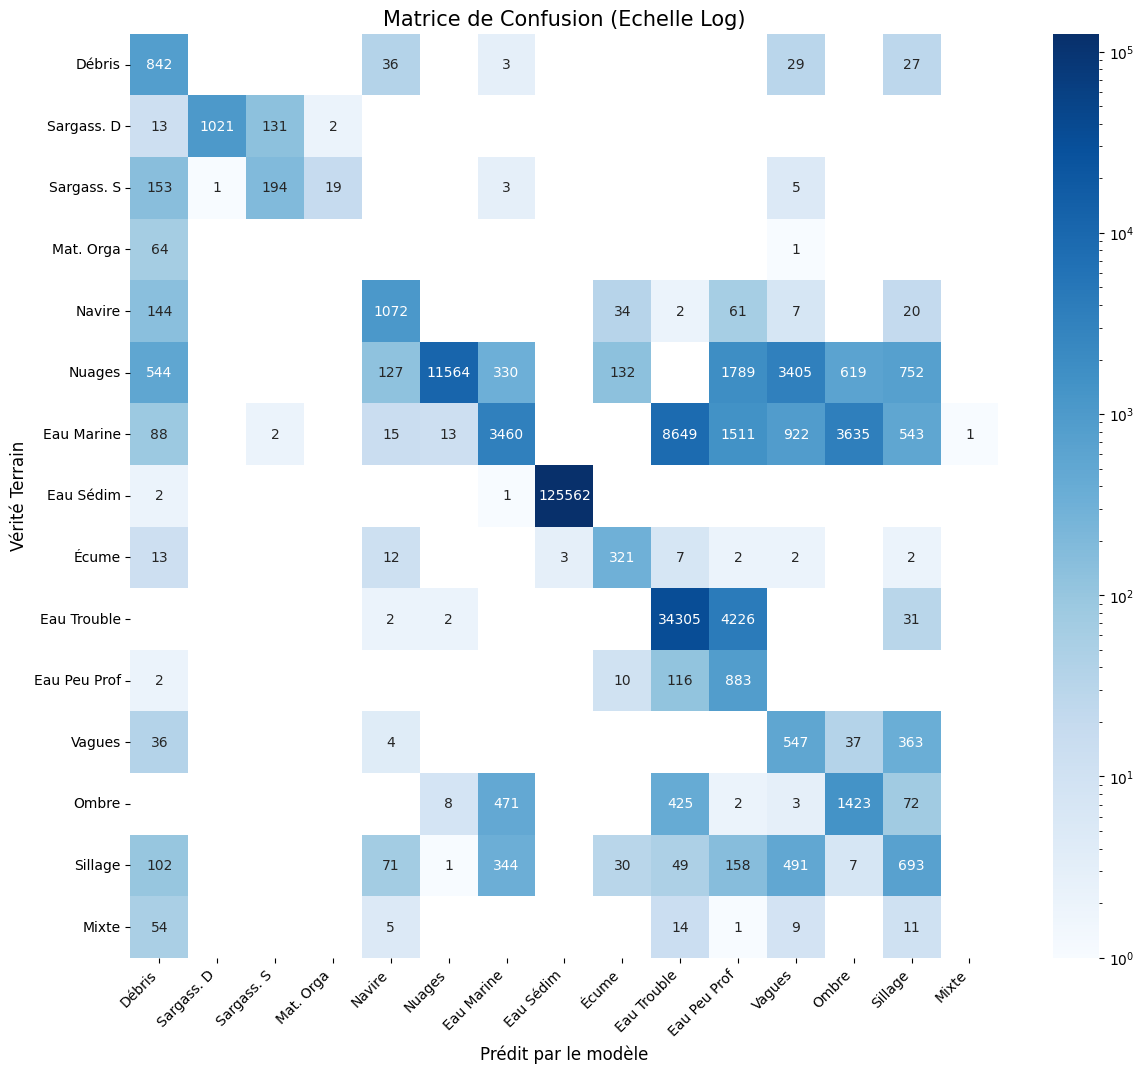

In [30]:


# 1. DÉFINITION DES NOMS DE CLASSES (0 à 14)
# (Ordre après décalage -1)
class_names = [
    'Débris', 'Sargass. D', 'Sargass. S', 'Mat. Orga', 'Navire',
    'Nuages', 'Eau Marine', 'Eau Sédim', 'Écume', 'Eau Trouble',
    'Eau Peu Prof', 'Vagues', 'Ombre', 'Sillage', 'Mixte'
]

def plot_confusion_matrix(model, loader, device):
    print(" Calcul de la matrice de confusion en cours...")
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, mask, conf in tqdm(loader, desc="Validation"):
            img = img.to(device)
            mask = mask.to(device)
            conf = conf.to(device)

            # --- MÊME LOGIQUE QUE L'ENTRAÎNEMENT ---
            # 1. Masque de confiance
            ignore_mask = build_conf_ignore_mask(conf, threshold=2)
            target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

            # 2. Décalage des classes (-1)
            valid_pixels = (target != -100)
            target[valid_pixels] = target[valid_pixels] - 1
            target[target == -1] = -100

            # 3. Prédiction
            outputs = model(img)
            preds = torch.argmax(outputs, dim=1)

            # 4. Filtrage (On garde uniquement les pixels valides pour la matrice)
            mask_valide = (target != -100)

            all_preds.append(preds[mask_valide].cpu().numpy())
            all_targets.append(target[mask_valide].cpu().numpy())

    # Concaténation
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    # Calcul de la matrice (lignes=Vrai, colonnes=Predit)
    cm = confusion_matrix(y_true, y_pred, labels=range(15))

    # --- AFFICHAGE GRAPHIQUE ---
    plt.figure(figsize=(14, 12))

    # On utilise une échelle logarithmique pour les couleurs car l'Eau écrase tout le reste
    sns.heatmap(
        cm,
        annot=True,         # Afficher les nombres
        fmt="d",            # Format entier
        cmap="Blues",       # Couleur bleue
        xticklabels=class_names,
        yticklabels=class_names,
        norm=LogNorm()      # Echelle log pour mieux voir les petites erreurs
    )

    plt.xlabel('Prédit par le modèle', fontsize=12)
    plt.ylabel('Vérité Terrain', fontsize=12)
    plt.title('Matrice de Confusion (Echelle Log)', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

# --- LANCEMENT ---
plot_confusion_matrix(model, val_loader, DEVICE)